In [ ]:
from typing import Any, Dict

import hydra
import numpy as np
import omegaconf
import torch
import pytorch_lightning as pl
import torch.nn as nn
from torch.nn import functional as F
from torch_scatter import scatter
from tqdm import tqdm

from cdvae.common.utils import PROJECT_ROOT
from cdvae.common.data_utils import (
    EPSILON, cart_to_frac_coords, mard, lengths_angles_to_volume,
    frac_to_cart_coords, min_distance_sqr_pbc)
from cdvae.pl_modules.embeddings import MAX_ATOMIC_NUM
from cdvae.pl_modules.embeddings import KHOT_EMBEDDINGS

#added by Tsach
from pymatgen.core.structure import Structure
from pymatgen.core.periodic_table import Element
from pymatgen.core.lattice import Lattice
from pymatgen.analysis.diffraction.xrd import XRDCalculator
#import Batch
from torch_geometric.data import Batch
xrd_calculator = XRDCalculator(wavelength='CuKa', symprec=0.1)
torch.set_printoptions(threshold=50000) # use this if you want to print the entire tensor
import matplotlib.pyplot as plt


In [1]:
 import time
import argparse
import torch

from tqdm import tqdm
from torch.optim import Adam
from pathlib import Path
from types import SimpleNamespace
from torch_geometric.data import Batch
from torch_geometric.data.separate import separate

#import a library that allows you to reload a module
from importlib import reload

from eval_utils import load_model

all_frac_coords_stack = []
all_atom_types_stack = []
frac_coords = []
num_atoms = []
atom_types = []
lengths = []
angles = []
input_data_list = []

#my code 
list_of_idxs = []
list_of_batchs = []


In [2]:
model_path = Path("/home/gridsan/tmackey/hydra/singlerun/2023-10-29/no_encode_intensity_concat_comp_concat_neg_mask_v3")
model, test_loader, cfg = load_model(model_path, True)

loader = test_loader

/home/gridsan/tmackey/.conda/envs/cdvae/lib/python3.8/site-packages/hydra/experimental/compose.py:16: UserWarning: hydra.experimental.compose() is no longer experimental. Use hydra.compose()
  warnings.warn(


using 3787 rows given a train_fraction of 1


  0%|          | 0/3787 [00:00<?, ?it/s]

/home/gridsan/tmackey/.conda/envs/cdvae/lib/python3.8/site-packages/pymatgen/io/cif.py:1168: UserWarning: Issues encountered while parsing CIF: Some fractional coordinates rounded to ideal values to avoid issues with finite precision.
  warnings.warn("Issues encountered while parsing CIF: " + "\n".join(self.warnings))
/home/gridsan/tmackey/.conda/envs/cdvae/lib/python3.8/site-packages/pymatgen/io/cif.py:1168: UserWarning: Issues encountered while parsing CIF: Some fractional coordinates rounded to ideal values to avoid issues with finite precision.
  warnings.warn("Issues encountered while parsing CIF: " + "\n".join(self.warnings))
/home/gridsan/tmackey/.conda/envs/cdvae/lib/python3.8/site-packages/pymatgen/io/cif.py:1168: UserWarning: Issues encountered while parsing CIF: Some fractional coordinates rounded to ideal values to avoid issues with finite precision.
  warnings.warn("Issues encountered while parsing CIF: " + "\n".join(self.warnings))
/home/gridsan/tmackey/.conda/envs/cdvae/

CrystDataModule(self.datasets={'train': {'_target_': 'cdvae.pl_data.dataset.CrystDataset', 'name': 'Formation energy train', 'path': '/home/gridsan/tmackey/cdvae/data/perov_5/train.csv', 'prop': 'heat_ref', 'niggli': True, 'primitive': False, 'graph_method': 'crystalnn', 'lattice_scale_method': 'scale_length', 'preprocess_workers': 30}, 'val': [{'_target_': 'cdvae.pl_data.dataset.CrystDataset', 'name': 'Formation energy val', 'path': '/home/gridsan/tmackey/cdvae/data/perov_5/val.csv', 'prop': 'heat_ref', 'niggli': True, 'primitive': False, 'graph_method': 'crystalnn', 'lattice_scale_method': 'scale_length', 'preprocess_workers': 30}], 'test': [{'_target_': 'cdvae.pl_data.dataset.CrystDataset', 'name': 'Formation energy test', 'path': '/home/gridsan/tmackey/cdvae/data/perov_5/test.csv', 'prop': 'heat_ref', 'niggli': True, 'primitive': False, 'graph_method': 'crystalnn', 'lattice_scale_method': 'scale_length', 'preprocess_workers': 30}]}, self.num_workers={'train': 0, 'val': 0, 'test': 0

/home/gridsan/tmackey/.conda/envs/cdvae/lib/python3.8/site-packages/torch_geometric/deprecation.py:13: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  warnings.warn(out)


In [3]:
for idx, batch in enumerate(loader):
    print(idx)
    list_of_idxs.append(idx)
    list_of_batchs.append(batch)

idx = list_of_idxs[0]
batch = list_of_batchs[0]


def new_dataloader_batch_processor(batch): 
    batch_reserve = batch
    xrd_int = batch_reserve[1]
    xrd_loc = batch_reserve[2]
    atom_spec = batch_reserve[3]
    disc_sim_xrd = batch_reserve[4]
    batch = batch[0]
    return batch_reserve, xrd_int, xrd_loc, atom_spec, disc_sim_xrd, batch

batch_reserve, xrd_int, xrd_loc, atom_spec, disc_sim_xrd, batch = new_dataloader_batch_processor(batch)

batch_all_frac_coords = []
batch_all_atom_types = []
batch_frac_coords, batch_num_atoms, batch_atom_types = [], [], []
batch_lengths, batch_angles = [], []


0
1
2
3
4
5
6
7
8
9
10
11
12
13
14


In [63]:
"""This module implements an XRD pattern calculator."""

from __future__ import annotations
import torch
import json
import os
from math import asin, cos, degrees, pi, radians, sin
from typing import TYPE_CHECKING
import matplotlib.pyplot as plt
import numpy as np
import torch.nn.functional as F

import pandas as pd


atom_names = {
	1: "H",
	2: "He",
	3: "Li",
	4: "Be",
	5: "B",
	6: "C",
	7: "N",
	8: "O",
	9: "F",
	10: "Ne",
	11: "Na",
	12: "Mg",
	13: "Al",
	14: "Si",
	15: "P",
	16: "S",
	17: "Cl",
	18: "Ar",
	19: "K",
	20: "Ca",
	21: "Sc",
	22: "Ti",
	23: "V",
	24: "Cr",
	25: "Mn",
	26: "Fe",
	27: "Co",
	28: "Ni",
	29: "Cu",
	30: "Zn",
	31: "Ga",
	32: "Ge",
	33: "As",
	34: "Se",
	35: "Br",
	36: "Kr",
	37: "Rb",
	38: "Sr",
	39: "Y",
	40: "Zr",
	41: "Nb",
	42: "Mo",
	43: "Tc",
	44: "Ru",
	45: "Rh",
	46: "Pd",
	47: "Ag",
	48: "Cd",
	49: "In",
	50: "Sn",
	51: "Sb",
	52: "Te",
	53: "I",
	54: "Xe",
	55: "Cs",
	56: "Ba",
	57: "La",
	58: "Ce",
	59: "Pr",
	60: "Nd",
	61: "Pm",
	62: "Sm",
	63: "Eu",
	64: "Gd",
	65: "Tb",
	66: "Dy",
	67: "Ho",
	68: "Er",
	69: "Tm",
	70: "Yb",
	71: "Lu",
	72: "Hf",
	73: "Ta",
	74: "W",
	75: "Re",
	76: "Os",
	77: "Ir",
	78: "Pt",
	79: "Au",
	80: "Hg",
	81: "Tl",
	82: "Pb",
	83: "Bi",
	84: "Po",
	85: "At",
	86: "Rn",
	87: "Fr",
	88: "Ra",
	89: "Ac",
	90: "Th",
	91: "Pa",
	92: "U",
	93: "Np",
	94: "Pu",
	95: "Am",
	96: "Cm",
	97: "Bk",
	98: "Cf"
}



atom_form_factor_constants = [
	[[0.202, 30.868], [0.244, 8.544], [0.082, 1.273], [0, 0]],
	[[0.091, 18.183], [0.181, 6.212], [0.11, 1.803], [0.036, 0.284]],
	[[1.611, 107.638], [1.246, 30.48], [0.326, 4.533], [0.099, 0.495]],
	[[1.25, 60.804], [1.334, 18.591], [0.36, 3.653], [0.106, 0.416]],
	[[0.945, 46.444], [1.312, 14.178], [0.419, 3.223], [0.116, 0.377]],
	[[0.731, 36.995], [1.195, 11.297], [0.456, 2.814], [0.125, 0.346]],
	[[0.572, 28.847], [1.043, 9.054], [0.465, 2.421], [0.131, 0.317]],
	[[0.455, 23.78], [0.917, 7.622], [0.472, 2.144], [0.138, 0.296]],
	[[0.387, 20.239], [0.811, 6.609], [0.475, 1.931], [0.146, 0.279]],
	[[0.303, 17.64], [0.72, 5.86], [0.475, 1.762], [0.153, 0.266]],
	[[2.241, 108.004], [1.333, 24.505], [0.907, 3.391], [0.286, 0.435]],
	[[2.268, 73.67], [1.803, 20.175], [0.839, 3.013], [0.289, 0.405]],
	[[2.276, 72.322], [2.428, 19.773], [0.858, 3.08], [0.317, 0.408]],
	[[2.129, 57.775], [2.533, 16.476], [0.835, 2.88], [0.322, 0.386]],
	[[1.888, 44.876], [2.469, 13.538], [0.805, 2.642], [0.32, 0.361]],
	[[1.659, 36.65], [2.386, 11.488], [0.79, 2.469], [0.321, 0.34]],
	[[1.452, 30.935], [2.292, 9.98], [0.787, 2.234], [0.322, 0.323]],
	[[1.274, 26.682], [2.19, 8.813], [0.793, 2.219], [0.326, 0.307]],
	[[3.951, 137.075], [2.545, 22.402], [1.98, 4.532], [0.482, 0.434]],
	[[4.47, 99.523], [2.971, 22.696], [1.97, 4.195], [0.482, 0.417]],
	[[3.966, 88.96], [2.917, 20.606], [1.925, 3.856], [0.48, 0.399]],
	[[3.565, 81.982], [2.818, 19.049], [1.893, 3.59], [0.483, 0.386]],
	[[3.245, 76.379], [2.698, 17.726], [1.86, 3.363], [0.486, 0.374]],
	[[2.307, 78.405], [2.334, 15.785], [1.823, 3.157], [0.49, 0.364]],
	[[2.747, 67.786], [2.456, 15.674], [1.792, 3.0], [0.498, 0.357]],
	[[2.544, 64.424], [2.343, 14.88], [1.759, 2.854], [0.506, 0.35]],
	[[2.367, 61.431], [2.236, 14.18], [1.724, 2.725], [0.515, 0.344]],
	[[2.21, 58.727], [2.134, 13.553], [1.689, 2.609], [0.524, 0.339]],
	[[1.579, 62.94], [1.82, 12.453], [1.658, 2.504], [0.532, 0.333]],
	[[1.942, 54.162], [1.95, 12.518], [1.619, 2.416], [0.543, 0.33]],
	[[2.321, 65.602], [2.486, 15.458], [1.688, 2.581], [0.599, 0.351]],
	[[2.447, 55.893], [2.702, 14.393], [1.616, 2.446], [0.601, 0.342]],
	[[2.399, 45.718], [2.79, 12.817], [1.529, 2.28], [0.594, 0.328]],
	[[2.298, 38.83], [2.854, 11.536], [1.456, 2.146], [0.59, 0.316]],
	[[2.166, 33.899], [2.904, 10.497], [1.395, 2.041], [0.589, 0.307]],
	[[2.034, 29.999], [2.927, 9.598], [1.342, 1.952], [0.589, 0.299]],
	[[4.776, 140.782], [3.859, 18.991], [2.234, 3.701], [0.868, 0.419]],
	[[5.848, 104.972], [4.003, 19.367], [2.342, 3.737], [0.88, 0.414]],
	[[4.129, 27.548], [3.012, 5.088], [1.179, 0.591], [0, 0]],
	[[4.105, 28.492], [3.144, 5.277], [1.229, 0.601], [0, 0]],
	[[4.237, 27.415], [3.105, 5.074], [1.234, 0.593], [0, 0]],
	[[3.12, 72.464], [3.906, 14.642], [2.361, 3.237], [0.85, 0.366]],
	[[4.318, 28.246], [3.27, 5.148], [1.287, 0.59], [0, 0]],
	[[4.358, 27.881], [3.298, 5.179], [1.323, 0.594], [0, 0]],
	[[4.431, 27.911], [3.343, 5.153], [1.345, 0.592], [0, 0]],
	[[4.436, 28.67], [3.454, 5.269], [1.383, 0.595], [0, 0]],
	[[2.036, 61.497], [3.272, 11.824], [2.511, 2.846], [0.837, 0.327]],
	[[2.574, 55.675], [3.259, 11.838], [2.547, 2.784], [0.838, 0.322]],
	[[3.153, 66.649], [3.557, 14.449], [2.818, 2.976], [0.884, 0.335]],
	[[3.45, 59.104], [3.735, 14.179], [2.118, 2.855], [0.877, 0.327]],
	[[3.564, 50.487], [3.844, 13.316], [2.687, 2.691], [0.864, 0.316]],
	[[4.785, 27.999], [3.688, 5.083], [1.5, 0.581], [0, 0]],
	[[3.473, 39.441], [4.06, 11.816], [2.522, 2.415], [0.84, 0.298]],
	[[3.366, 35.509], [4.147, 11.117], [2.443, 2.294], [0.829, 0.289]],
	[[6.062, 155.837], [5.986, 19.695], [3.303, 3.335], [1.096, 0.379]],
	[[7.821, 117.657], [6.004, 18.778], [3.28, 3.263], [1.103, 0.376]],
	[[4.94, 28.716], [3.968, 5.245], [1.663, 0.594], [0, 0]],
	[[5.007, 28.283], [3.98, 5.183], [1.678, 0.589], [0, 0]],
	[[5.085, 28.588], [4.043, 5.143], [1.684, 0.581], [0, 0]],
	[[5.151, 28.304], [4.075, 5.073], [1.683, 0.571], [0, 0]],
	[[5.201, 28.079], [4.094, 5.081], [1.719, 0.576], [0, 0]],
	[[5.255, 28.016], [4.113, 5.037], [1.743, 0.577], [0, 0]],
	[[5.267, 28.016], [4.113, 5.037], [1.743, 0.577], [0, 0]],
	[[5.225, 29.158], [4.314, 5.259], [1.827, 0.586], [0, 0]],
	[[5.272, 29.046], [4.347, 5.226], [1.844, 0.585], [0, 0]],
	[[5.332, 28.888], [4.37, 5.198], [1.863, 0.581], [0, 0]],
	[[5.376, 28.773], [4.403, 5.174], [1.884, 0.582], [0, 0]],
	[[5.436, 28.655], [4.437, 5.117], [1.891, 0.577], [0, 0]],
	[[5.441, 29.149], [4.51, 5.264], [1.956, 0.59], [0, 0]],
	[[5.529, 28.927], [4.533, 5.144], [1.945, 0.578], [0, 0]],
	[[5.553, 28.907], [4.58, 5.16], [1.969, 0.577], [0, 0]],
	[[5.588, 29.001], [4.619, 5.164], [1.997, 0.579], [0, 0]],
	[[5.659, 28.807], [4.63, 5.114], [2.014, 0.578], [0, 0]],
	[[5.709, 28.782], [4.677, 5.084], [2.019, 0.572], [0, 0]],
	[[5.695, 28.968], [4.74, 5.156], [2.064, 0.575], [0, 0]],
	[[5.75, 28.933], [4.773, 5.139], [2.079, 0.573], [0, 0]],
	[[5.754, 29.159], [4.851, 5.152], [2.096, 0.57], [0, 0]],
	[[5.803, 29.016], [4.87, 5.15], [2.127, 0.572], [0, 0]],
	[[2.388, 42.866], [4.226, 9.743], [2.689, 2.264], [1.255, 0.307]],
	[[2.682, 42.822], [4.241, 9.856], [2.755, 2.295], [1.27, 0.307]],
	[[5.932, 29.086], [4.972, 5.126], [2.195, 0.572], [0, 0]],
	[[3.51, 52.914], [4.552, 11.884], [3.154, 2.571], [1.359, 0.321]],
	[[3.841, 50.261], [4.679, 11.999], [3.192, 2.56], [1.363, 0.318]],
	[[6.07, 28.075], [4.997, 4.999], [2.232, 0.563], [0, 0]],
	[[6.133, 28.047], [5.031, 4.957], [2.239, 0.558], [0, 0]],
	[[4.078, 38.406], [4.978, 11.02], [3.096, 2.355], [1.326, 0.299]],
	[[6.201, 28.2], [5.121, 4.954], [2.275, 0.556], [0, 0]],
	[[6.215, 28.382], [5.17, 5.002], [2.316, 0.562], [0, 0]],
	[[6.278, 28.323], [5.195, 4.949], [2.321, 0.557], [0, 0]],
	[[6.264, 28.651], [5.263, 5.03], [2.367, 0.563], [0, 0]],
	[[6.306, 28.688], [5.303, 5.026], [2.386, 0.561], [0, 0]],
	[[6.767, 85.951], [6.729, 15.642], [4.014, 2.936], [1.561, 0.335]],
	[[6.323, 29.142], [5.414, 5.096], [2.453, 0.568], [0, 0]],
	[[6.415, 28.836], [5.419, 5.022], [2.449, 0.561], [0, 0]],
	[[6.462, 28.396], [5.469, 4.97], [2.471, 0.554], [0, 0]],
	[[6.46, 28.396], [5.469, 4.97], [2.471, 0.554], [0, 0]],
	[[6.502, 28.375], [5.478, 4.975], [2.51, 0.561], [0, 0]],
	[[6.548, 28.461], [5.526, 4.965], [2.52, 0.557], [0, 0]],
	[[6.58, 28.543], [5.572, 4.958], [2.538, 0.555], [0, 0]],
	[[6.61, 28.621], [5.615, 4.954], [2.553, 0.553], [0, 0]],
	[[6.638, 28.695], [5.655, 4.952], [2.566, 0.552], [0, 0]],
	[[6.665, 28.765], [5.692, 4.952], [2.577, 0.551], [0, 0]],
	[[6.69, 28.832], [5.727, 4.954], [2.587, 0.55], [0, 0]],
	[[6.713, 28.896], [5.759, 4.958], [2.596, 0.549], [0, 0]],
	[[6.735, 28.957], [5.789, 4.963], [2.604, 0.548], [0, 0]],
	[[6.756, 29.015], [5.817, 4.969], [2.611, 0.547], [0, 0]],
	[[6.776, 29.071], [5.843, 4.976], [2.618, 0.546], [0, 0]],
	[[6.795, 29.124], [5.867, 4.984], [2.624, 0.545], [0, 0]],
	[[6.813, 29.175], [5.89, 4.992], [2.63, 0.544], [0, 0]],
	[[6.831, 29.224], [5.912, 5.001], [2.635, 0.543], [0, 0]],
	[[6.848, 29.271], [5.932, 5.01], [2.64, 0.542], [0, 0]],
	[[6.864, 29.316], [5.951, 5.019], [2.645, 0.541], [0, 0]],
	[[6.88, 29.36], [5.969, 5.028], [2.649, 0.541], [0, 0]],
	[[6.895, 29.402], [5.986, 5.038], [2.653, 0.54], [0, 0]],
	[[6.909, 29.443], [6.002, 5.047], [2.657, 0.539], [0, 0]],
	[[6.923, 29.483], [6.017, 5.057], [2.661, 0.539], [0, 0]],
	[[6.936, 29.522], [6.031, 5.066], [2.664, 0.538], [0, 0]],
	[[6.949, 29.56], [6.044, 5.076], [2.667, 0.538], [0, 0]],
]



def get_cell_matrix(structure):
    # angles = torch.tensor(structure[0], requires_grad=True)
    # lengths = torch.tensor(structure[1], requires_grad=True)
    
    angles = structure[0]
    lengths = structure[1]

    angles_rad = angles * 3.14 / 180

    a_vector = torch.tensor([1, 0, 0]) * lengths[0]
    b_vector = (torch.tensor([1,0,0]) * torch.cos(angles_rad[2]) + torch.tensor([0,1,0]) * torch.sin(angles_rad[2])) * lengths[1]
    c_vector = (torch.tensor([1,0,0]) * torch.cos(angles_rad[1]) + torch.tensor([0,1,0]) * ((torch.cos(angles_rad[0]) - torch.cos(angles_rad[1]) * torch.cos(angles_rad[2])) /  torch.sin(angles_rad[2])) + torch.tensor([0,0,1]) * torch.sqrt(1 - torch.square(torch.cos(angles_rad[1])) - torch.square((torch.cos(angles_rad[0]) - torch.cos(angles_rad[1]) * torch.cos(angles_rad[2])) / torch.sin(angles_rad[2]))) )* lengths[2]
    cell_matrix = torch.stack((a_vector,b_vector, c_vector))
    return cell_matrix


def collect_recip_latt_points(cell_matrix, q_max):
    

    # Obtained from Bragg condition. Note that reciprocal lattice
    # vector length is 1 / d_hkl.
    recip_latt = torch.linalg.inv(cell_matrix).T

    max_r = q_max / (2 * 3.14)

    max_h = round(max_r / float(torch.linalg.norm(recip_latt[0])))
    max_k = round(max_r / float(torch.linalg.norm(recip_latt[1])))
    max_l = round(max_r / float(torch.linalg.norm(recip_latt[2])))

    hkl_pts = get_points_in_sphere(max_h, max_k, max_l)
    recip_pts = torch.mm(hkl_pts, recip_latt)
    recip_lengths = torch.linalg.norm(recip_pts, dim = 1)
    return hkl_pts, recip_lengths


def get_points_in_sphere(max_h, max_k, max_l):
    # Create a matrix of ones representing the reciprocal lattice
    hkl_ones_matrix = torch.ones((max_h*2 + 1, max_k*2 + 1, max_l*2 + 1))

    # Get the indices of every point in that lattice and flatten it into a [n, 3] list
    hkl_pts = torch.nonzero(hkl_ones_matrix, as_tuple=False) - torch.Tensor([max_h, max_k, max_l])

    # Calculate the radius squared for comparison (to avoid square root for efficiency)
    radius_squared = max_h**2 + max_k**2 + max_l**2

    # Filter out the points that are outside the sphere
    distances_squared = torch.sum(hkl_pts**2, dim=1)
    hkl_pts_in_sphere = hkl_pts[distances_squared <= radius_squared]

    # Remove the incident beam from the list of hkl points (point at the center)
    center = torch.tensor([0, 0, 0])
    hkl_pts_in_sphere = hkl_pts_in_sphere[torch.any(hkl_pts_in_sphere != center, dim=1)]

    return hkl_pts_in_sphere


def get_fcoords_occus_zs_coeffs(structure):
    # fcoords = torch.tensor(structure[2], requires_grad = True)
    # occus = torch.tensor(structure[3], requires_grad = True)
    # zs = torch.tensor(structure[4])
    fcoords = structure[2]
    occus = structure[3]
    zs = structure[4]

    coeffs = []

    # Collect the coefficients for each element in the structure into a torch tensor from the atom_form_factor_constants dictionary
    coeffs = torch.tensor(atom_form_factor_constants, dtype=torch.float32)
    coeffs = coeffs[zs - 1]

    return fcoords, occus, zs, coeffs


def calc_atomic_scattering_factor(zs, recip_lengths, coeffs):
	#Add additional dimension to the r^2 list for each hkl
	squared_recip_lengths = torch.square(recip_lengths/2).unsqueeze(0)

	# Calculate the exponentiated component of the fitted atomic scattering factor
	extinct_exp = torch.exp(-coeffs[:, :, 1].unsqueeze(2) * squared_recip_lengths)
	
	# Calculate the whole of the fitted atomic scattering factor function
	fitted_factor = torch.sum(coeffs[:, :, 0].unsqueeze(2) * extinct_exp, axis = 1)

	# Calculate the full angle dependent component of the atomic scattering factor
	angle_fs = 41.78214 * squared_recip_lengths * fitted_factor

	# Calculate the atomic scattering factor for each hkl
	fs = zs.unsqueeze(1) - angle_fs

	return fs

def calc_lorentz_factor(recip_lengths, wavelength):
    # Calculate a theta list from r's
    #theta = torch.asin(wavelength * recip_lengths / 2)

    # Calculate how the intensity of peaks are expected to tail off due to geometric constraints of experiments
    #lorentz_factor = (1 + torch.square(torch.cos(2 * theta))) / (torch.square(torch.sin(theta)) * torch.cos(theta))

    """Another way to calculate it without trig functions is
    x = wavelength * recip_lengths / 2
    lorentz_factor = -(4 * torch.square(torch.square(x)) + 4 * torch.square(x) - 2) / (torch.square(x) * torch.sqrt(1 - torch.square(x)))
    """

    x = wavelength * recip_lengths / 2
    lorentz_factor = -(4 * torch.square(torch.square(x)) + 4 * torch.square(x) - 2) / (torch.square(x) * torch.sqrt(1 - torch.square(x)))

    return lorentz_factor



def diffraction_calc(structure, q_max, wavelength):
    # default q_max should be 4 * pi / wavelength
    # Calculate the cell matrix
    cell_matrix = get_cell_matrix(structure)

    # Get all the hkl points that satisfy the chosen q_max and put them in a list
    # Also put the r of the lattice point in a different list
    hkl_pts, recip_lengths = collect_recip_latt_points(cell_matrix, q_max)

    # Collect all the information on the atoms
    fcoords, occus, zs, coeffs = get_fcoords_occus_zs_coeffs(structure)

    # Calculate the atom positions times each set of hkl indices
    g_dot_r = torch.mm(hkl_pts, fcoords.T)

    # Calculate the atomic scattering factors at each r (or angle)
    fs = calc_atomic_scattering_factor(zs, recip_lengths, coeffs)

    # Multiply the atomic scattering factors by the occupation of each site
    w_fs = torch.mm(occus, fs)

    # Calculate the complex phase and intensity of the scattering for each hkl
    f_hkl = torch.sum(w_fs.T * torch.exp(2j * 3.14 * g_dot_r), axis = 1)

    # Calculate the real instensity for each hkl
    i_hkl = (f_hkl * torch.conj(f_hkl)).real

    # Calculate the lorentz factor based on the recip lengths
    lorentz_factor = calc_lorentz_factor(recip_lengths, wavelength)

    # Calculate two theta values from recip lengths and turn into degrees from rad
    # two_thetas = 2 * torch.asin(wavelength * recip_lengths / 2) * 180 / pi
    clamped_input = torch.clamp(wavelength * recip_lengths / 2, min=-1, max=1)
    two_thetas = (360 / 3.14) * torch.asin(clamped_input)

    #Calculate intensities from i_hkl and correction factor (lorentz_factor)
    intensities = i_hkl * 1 # changed to allow back prop

    # Wrap the two thetas and intensities together
    pattern = torch.stack((two_thetas, intensities))

    # Remove all reflections which have unphysical angles/positions
    pattern = pattern.T
    filtered_pattern = pattern[~torch.any(pattern.isnan(), dim = 1)]
    
    return filtered_pattern



def bin_pattern_theta(diffraction_pattern, wavelength, q_min = 0.5, q_max = 8, num_steps = 256, fraction_gaussian = 0.5, fwhm = 1):
    # This function is written to work in degrees, it can be used for q instead, but fwhm should change, and the step size should be calculated differently

    # Calculate the theta range
    two_theta_min = np.arcsin((q_min * wavelength) / (4 * 3.14)) * 360 / 3.14
    two_theta_max = np.arcsin((q_max * wavelength) / (4 * 3.14)) * 360 / 3.14

    # Calculate the width of each bin

    step_size = (two_theta_max - two_theta_min) / num_steps

    # Calculate prefactors for the pseudo-Voigt peak
    #ag = (2 / fwhm) * np.sqrt(np.log(2) / pi)
    ag = 0.9394372787 / fwhm
    #bg = (4 * np.log(2)) / (fwhm**2)
    bg = 2.77258872224 / (fwhm**2)

    # Make a tensor for the domain of the pattern
    pattern_domain = torch.arange(num_steps) * step_size + two_theta_min

    # Setup a domain for each peak in diffraction_pattern
    peaks = torch.ones((len(diffraction_pattern))) * pattern_domain.unsqueeze(1)

    # Calculate the gaussian component of the peak
    gaussian_peak = fraction_gaussian * ag * torch.exp(-bg * torch.square(peaks - diffraction_pattern[:, 0]))

    # Calculate the lorentzian component of the peak
    lorentz_peak = (1 - fraction_gaussian) * fwhm / (6.28318530718 * (torch.square(peaks - diffraction_pattern[:, 0]) + (fwhm/2)**2))

    # Calculate the combined peak
    combined_peak = diffraction_pattern[:, 1] * (gaussian_peak + lorentz_peak)

    # Sum over all peaks to get the binned pattern
    binned_pattern = torch.sum(combined_peak, axis = 1)
    return binned_pattern

def pymatgen_pattern(pattern):
    two_thetas = [0]
    temp_pattern = torch.Tensor([[0,0]])
    for i in range(pattern.size()[0]):
        if pattern[i, 1] > 0.001:
            ind = torch.where(torch.abs(torch.Tensor(two_thetas) - pattern[i, 0]) < 0.1)
            if ind[0].size()[0] > 0:
                temp_pattern[ind[0]][0][1] = temp_pattern[ind[0]][0][1] + pattern[i][1]
            else:
                temp_pattern = torch.cat((temp_pattern, pattern[i].unsqueeze(0)))
                two_thetas.append(pattern[i][0])
    print(temp_pattern)


In [11]:
def diffraction_loss(binned_ref_pattern, binned_gen_pattern, wavelength = 1.54184, q_max = 4):
    # print(binned_ref_pattern.shape)
    # print(binned_gen_pattern.shape)
    
    binned_ref_pattern = binned_ref_pattern.unsqueeze(0)
    binned_gen_pattern = binned_gen_pattern.unsqueeze(0)
    
    loss = -1*F.cosine_similarity(binned_ref_pattern, binned_gen_pattern)
    
    return loss

When I was calculating the discrete simulated xrds for the model, I set the lower_bound = 5, upper_bound = 75, dimensions = 200

In [72]:
batch_reserve, xrd_int, xrd_loc, atom_spec, disc_sim_xrd, batch

([Batch(edge_index=[2, 8258], y=[256, 1], frac_coords=[1280, 3], atom_types=[1280], lengths=[256, 3], angles=[256, 3], to_jimages=[8258, 3], num_atoms=[256], num_bonds=[256], num_nodes=1280, batch=[1280], ptr=[257]),
  tensor([[ 22.7943, 100.0000,  24.7243,  ...,   0.0000,   0.0000,   0.0000],
          [  6.5466, 100.0000,  14.7493,  ...,   0.0000,   0.0000,   0.0000],
          [ 68.3639, 100.0000,   9.2554,  ...,   0.0000,   0.0000,   0.0000],
          ...,
          [ 11.1589, 100.0000,   2.0070,  ...,   0.0000,   0.0000,   0.0000],
          [  2.5914, 100.0000,   2.1443,  ...,   0.0000,   0.0000,   0.0000],
          [  3.5411, 100.0000,  13.3442,  ...,   0.0000,   0.0000,   0.0000]]),
  tensor([[21.0694, 29.9696, 36.9237,  ...,  0.0000,  0.0000,  0.0000],
          [21.4675, 30.5427, 37.6388,  ...,  0.0000,  0.0000,  0.0000],
          [22.4884, 32.0145, 39.4779,  ...,  0.0000,  0.0000,  0.0000],
          ...,
          [19.3729, 27.5312, 33.8869,  ...,  0.0000,  0.0000,  0.00

In [20]:
index = 0

In [24]:

def one_hot_encode(numbers, n_classes=100):
    """
    Convert a list of numbers into a one-hot encoded matrix.

    Parameters:
    numbers (list): List of numbers.
    n_classes (int): Number of classes for one-hot encoding.

    Returns:
    numpy.ndarray: One-hot encoded matrix.
    """
    # Create a matrix of zeros
    one_hot_matrix = np.zeros((len(numbers), n_classes))

    # Set the appropriate elements to 1
    for i, num in enumerate(numbers):
        if 1 <= num <= n_classes:
            one_hot_matrix[i, num - 1] = 1  # subtract 1 because array indices start at 0

    return one_hot_matrix

In [54]:
angles_ref = batch.angles[index]
lengths_ref = batch.lengths[index]
atom_positions_ref = batch.frac_coords[torch.sum(batch.num_atoms[:index]):batch.num_atoms[index]]
atom_types_ref = batch.atom_types[torch.sum(batch.num_atoms[:index]):batch.num_atoms[index]]
zs_ref = np.arange(0,100)
atom_types_ref = torch.tensor(one_hot_encode(atom_types_ref), dtype=torch.float32)
zs_ref = torch.tensor(zs_ref)
structure_ref = [angles_ref, lengths_ref, atom_positions_ref, atom_types_ref, zs_ref]

In [ ]:
structure_ref

[tensor([90., 90., 90.]),
 tensor([4.2166, 4.2166, 4.2166]),
 tensor([[0.5061, 0.5000, 0.5000],
         [0.0014, 0.0000, 0.0000],
         [0.4979, 0.0000, 0.5000],
         [0.5014, 0.5000, 0.0000],
         [0.0036, 0.5000, 0.5000]]),
 tensor([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0

In [ ]:
xrd_int[0].shape

torch.Size([256])

In [ ]:
xrd_int[0].loc

AttributeError: 'Tensor' object has no attribute 'loc'

In [71]:
combined = torch.tensor(np.column_stack((np.array(pattern.x), np.array(pattern.y))))
pymatgen_adjusted = pymatgen_pattern(combined)

5.00691555255887
75.0079121636109


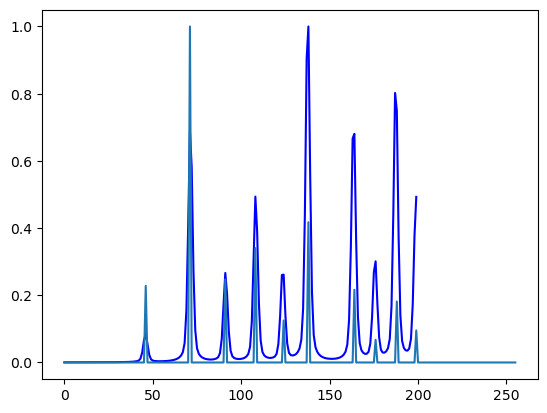

In [88]:
q_min = 0.356 #changed to match new data
num_steps = 200
wavelength = 1.54184
q_max = 4.962

ref_pattern = diffraction_calc(structure_ref, q_max, wavelength)
binned_ref_pattern = bin_pattern_theta(ref_pattern, wavelength, q_max = q_max, q_min=q_min, num_steps = num_steps)

#normalize all
binned_ref_pattern /= torch.max(binned_ref_pattern)

two_theta_min = np.arcsin((q_min * wavelength) / (4 * pi)) * 360 / pi
two_theta_max = np.arcsin((q_max * wavelength) / (4 * pi)) * 360 / pi
print(two_theta_min)
print(two_theta_max)
step_size = (two_theta_max - two_theta_min) / num_steps
domain = np.arange(len(binned_ref_pattern)) * step_size + two_theta_min
plt.plot(binned_ref_pattern.detach().numpy(), color = "blue")
plt.plot(disc_sim_xrd[0] / torch.max(disc_sim_xrd[0]))
plt.savefig("diffraction_loss.png")

In [68]:
disc_sim_xrd[0][:200].shape

torch.Size([200])

In [69]:
binned_ref_pattern.detach().numpy()

array([3.77683929e-04, 3.85699823e-04, 3.94038332e-04, 4.02720092e-04,
       4.11768066e-04, 4.21206816e-04, 4.31063847e-04, 4.41369280e-04,
       4.52156150e-04, 4.63461532e-04, 4.75325971e-04, 4.87795332e-04,
       5.00920403e-04, 5.14758576e-04, 5.29374811e-04, 5.44842100e-04,
       5.61243971e-04, 5.78676059e-04, 5.97248552e-04, 6.17088750e-04,
       6.38345431e-04, 6.61192986e-04, 6.85837644e-04, 7.12526147e-04,
       7.41554482e-04, 7.73283246e-04, 8.08155048e-04, 8.46720068e-04,
       8.89671792e-04, 9.37895675e-04, 9.92541201e-04, 1.05512585e-03,
       1.12769369e-03, 1.21305883e-03, 1.31519220e-03, 1.43985986e-03,
       1.59570831e-03, 1.79620413e-03, 2.06327345e-03, 2.43455940e-03,
       2.97932536e-03, 3.84886772e-03, 5.61000872e-03, 1.12071363e-02,
       2.96438653e-02, 6.59357831e-02, 8.56274813e-02, 5.48659749e-02,
       2.27745883e-02, 9.36536118e-03, 5.66234253e-03, 4.48231213e-03,
       3.94820888e-03, 3.70201725e-03, 3.63320718e-03, 3.69229913e-03,
      

In [70]:
diffraction_loss(binned_ref_pattern, disc_sim_xrd[0][:200])

tensor([-0.5055])

In [65]:
_, _, z = model.encode(batch, xrd_int, xrd_loc, atom_spec, disc_sim_xrd, testing = True)

RuntimeError: All input tensors must be on the same device. Received cpu and cuda:0

In [16]:
#number of steps set unusually low to get a rough estimate of performance
ld_kwargs = SimpleNamespace(n_step_each=10,
                                step_lr=1e-4,
                                min_sigma=0,
                                save_traj=False,
                                disable_bar=False)

force_num_atoms = True

gt_num_atoms = batch.num_atoms

gt_atom_types = None

z = z.to('cuda:0')
gt_num_atoms = gt_num_atoms.to('cuda:0')
atom_spec = atom_spec.to('cuda:0')
model.to('cuda:0')

CDVAE(
  (encoder): DimeNetPlusPlusWrap(
    (rbf): BesselBasisLayer(
      (envelope): Envelope()
    )
    (sbf): SphericalBasisLayer(
      (envelope): Envelope()
    )
    (emb): EmbeddingBlock(
      (emb): Embedding(95, 128)
      (lin_rbf): Linear(in_features=6, out_features=128, bias=True)
      (lin): Linear(in_features=384, out_features=128, bias=True)
    )
    (output_blocks): ModuleList(
      (0): OutputPPBlock(
        (lin_rbf): Linear(in_features=6, out_features=128, bias=False)
        (lin_up): Linear(in_features=128, out_features=256, bias=True)
        (lins): ModuleList(
          (0): Linear(in_features=256, out_features=256, bias=True)
          (1): Linear(in_features=256, out_features=256, bias=True)
          (2): Linear(in_features=256, out_features=256, bias=True)
        )
        (lin): Linear(in_features=256, out_features=256, bias=False)
      )
      (1): OutputPPBlock(
        (lin_rbf): Linear(in_features=6, out_features=128, bias=False)
        (lin

In [17]:
outputs = model.langevin_dynamics(
    z, ld_kwargs, gt_num_atoms, gt_atom_types, atom_spec)

/home/gridsan/tmackey/cdvae/cdvae/common/data_utils.py:625: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X = torch.tensor(X, dtype=torch.float)
100%|██████████| 50/50 [01:09<00:00,  1.39s/it]
